# Beijing PM2.5 — merged solution

Combines the two independent attempts, taking whichever construction is better on each axis rather than
unioning both feature sets (union adds correlated noise and slows everything down for no gain).

| Axis | Taken from | Why |
|---|---|---|
| Lead / nowcast block | **B** | Found it; we didn't. Gated behind `STRICT_MODE` — read §0 |
| PM10 × RH hygroscopic family | **B** | Physically motivated, reported top gain by 3× |
| Time-range rolling windows | **B** | `rangeBetween` on hour index; ours were row-based and span gaps |
| Size-weighted refit rounds | **B** | Early folds train on less data; their optima aren't comparable |
| LOFO-guarded calibration | **B** | Fitted out-of-fold and checked out-of-fold |
| Recency half-life grid | **B** | Tuned rather than assumed |
| Seed averaging | **B** | Implemented rather than deferred |
| Nowcast anchor | **A** | Synthetic PM2.5 history; B rejected the label version, correctly, but stopped there |
| Missingness flags + causal ffill | **A** | CO is 4.4% missing in train vs 1.5% in test — that asymmetry is signal |
| Leave-one-out network means | **A** | B's `city_*` includes the station's own value in its own reference |
| Data-derived station adjacency | **A** | Spatial structure without external metadata |
| Chinese New Year | **A** | 28 Jan 2017 falls inside the test window |
| Heating season 15 Nov – 15 Mar | **A** | B's `month>=11 or <=3` is ~5 weeks too wide at each end |
| Model diversity + drift check | **A** | More decorrelated members for the blend |
| Season-matched CV | **both** | Independently arrived at. The one decision that matters most |

`preprocess.py` from repo A supplies the 355-feature base. Everything below is additive.

## 0. The lead block — decide this deliberately

`STRICT_MODE = False` enables predictors from hour *t+1*: `PM10_lead1`, `RH_lead1`, `CO_lead1` and
derived forms. Where this actually sits:

- It does **not** recover hidden targets. `PM2_5_next_hour` is absent from `test.csv`. The README's
  explicit prohibition is not violated.
- It **does** contradict the README's framing of the task, which describes each row as information
  "available at the observation hour". No operational warning system has hour *t+1* measurements at
  hour *t*. This turns forecasting into nowcasting.
- It is available for ~98% of test rows, and it is large. `PM10_lead1 × RH_lead1` is close to a direct
  physical estimator of the target.

Ask the organisers before you submit anything produced with `STRICT_MODE = False`. In a datathon with
methodology judging, winning this way can cost more than it gains. The default here is strict.

Run both modes regardless — the gap between them tells you exactly what the block is worth, and you
need that number to have the conversation.

In [1]:
from pathlib import Path
import os, sys, json, gc, warnings, subprocess, time
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

REPO = Path(".")                      # holds train.csv, test.csv, preprocess.py
PROC = REPO / "data" / "processed"
OUT  = REPO / "outputs"; OUT.mkdir(parents=True, exist_ok=True)

# --- the decision from section 0 ------------------------------------------
STRICT_MODE = True     # True = no t+1 predictors (defensible). False = lead/nowcast block on.

# --- everything else -------------------------------------------------------
SEED          = 42
SEEDS         = [42, 202, 777]      # seed averaging in the final refit
N_THREADS     = max(1, (os.cpu_count() or 4) - 1)
QUICK         = False               # 1 fold, short boosting, no NN -- smoke test

USE_ANCHOR    = True                # section 6: synthetic PM2.5 history
USE_HYGRO     = True                # section 5: PM10 x RH family
USE_ADJACENCY = True                # section 4: data-derived station neighbours
USE_COORDS    = False               # external lat/lon -- confirm with organisers first
USE_TORCH     = True
TUNE_RECENCY  = True
HALFLIFE_GRID = [None, 1095, 730, 365, 180]   # days
CALIBRATE     = True

TARGET, ID, TIME = "PM2_5_next_hour", "id", "observation_timestamp"
CATS       = ["station", "wd"]
DROP_DRIFT = ["year", "hours_from_start", "day"]
TEST_START = pd.Timestamp("2016-08-31 23:00")
Y_MIN, Y_MAX = 2.0, 999.0            # observed train target range
N_TEST_EXPECTED = 51063

np.random.seed(SEED)
print(f"strict={STRICT_MODE}  threads={N_THREADS}  quick={QUICK}")

strict=True  threads=15  quick=False


## 1. Load

`preprocess.py` supplies exact clock-hour lags, leave-one-out network features, per-column missingness
flags and causal 6-hour forward-fill with an age feature. Run automatically if the parquets are absent.

In [2]:
if not (PROC / "train_processed.parquet").exists():
    print("running preprocess.py ...")
    subprocess.run([sys.executable, str(REPO / "preprocess.py"), "--out-dir", str(PROC)], check=True)

meta = json.load(open(PROC / "feature_metadata.json"))
FEATS_BASE = [c for c in meta["feature_columns"] if c not in DROP_DRIFT]

train = pd.read_parquet(PROC / "train_processed.parquet")
test  = pd.read_parquet(PROC / "test_processed.parquet")
for d in (train, test):
    d[TIME] = pd.to_datetime(d[TIME])

assert TARGET not in test.columns
assert "current_PM2_5" not in train.columns
assert train[ID].is_unique and test[ID].is_unique
assert train[TIME].max() < test[TIME].min()
assert len(test) == N_TEST_EXPECTED

print(f"train {train.shape}  test {test.shape}  base features {len(FEATS_BASE)}")
print(f"train {train[TIME].min()} -> {train[TIME].max()}")
print(f"test  {test[TIME].min()} -> {test[TIME].max()}")
print(train[TARGET].describe().round(2).to_string())

train (360954, 358)  test (51063, 357)  base features 352
train 2013-03-01 00:00:00 -> 2016-08-31 22:00:00
test  2016-08-31 23:00:00 -> 2017-02-28 22:00:00
count    360954.00
mean         78.04
std          77.78
min           2.00
25%          21.00
50%          55.00
75%         108.00
max         999.00


## 2. Season-matched folds

Both attempts arrived at this independently and it is the single most consequential decision in the
notebook. Test is September–February. A tail holdout gives you March–August, the clean season, and it
will lie to you by several RMSE points.

Fold generation follows B's automatic construction rather than a hand-written list.

In [3]:
def season_folds(ts, min_train=30_000, min_valid=5_000):
    # Train through 31 Aug, validate 1 Sep -> 28 Feb. Mirrors the real split.
    out = []
    for yr in sorted(ts.dt.year.unique()):
        cut, end = pd.Timestamp(f"{yr}-09-01"), pd.Timestamp(f"{yr+1}-03-01")
        itr = np.where(ts < cut)[0]
        iva = np.where((ts >= cut) & (ts < end))[0]
        if len(itr) >= min_train and len(iva) >= min_valid:
            out.append((f"S{yr}", itr, iva))
    return out

ts_tr = train[TIME]
FOLDS = season_folds(ts_tr)
if QUICK:
    FOLDS = FOLDS[-1:]

# Off-season diagnostic fold. Never used for selection -- it is the wrong regime.
_d_tr = np.where(ts_tr < pd.Timestamp("2016-03-01"))[0]
_d_va = np.where((ts_tr >= pd.Timestamp("2016-03-01")) & (ts_tr < TEST_START))[0]
DIAG = ("offseason", _d_tr, _d_va)

def rmse(a, p):
    a, p = np.asarray(a, float), np.asarray(p, float)
    return float(np.sqrt(np.mean((a - p) ** 2)))

for n, a, b in FOLDS:
    print(f"{n:8s} train={len(a):>7,}  valid={len(b):>6,}  valid_mean={train[TARGET].values[b].mean():6.1f}")
print(f"\n{len(FOLDS)} season-matched folds  |  test rows {len(test):,}")

S2013    train= 51,925  valid=51,442  valid_mean=  93.5
S2014    train=155,190  valid=50,799  valid_mean=  86.8
S2015    train=257,927  valid=51,349  valid_mean=  83.2

3 season-matched folds  |  test rows 51,063


## 3. Baselines

Establish the floor before touching a model. B's group-mean baseline (station × month × hour) is the
strongest of the three and the one worth beating comfortably.

In [4]:
rows = []
for name, itr, iva in FOLDS:
    ytr, yva = train[TARGET].values[itr], train[TARGET].values[iva]
    r_mean = rmse(yva, np.full(len(yva), ytr.mean()))
    med = train["PM10"].values[itr]
    m_ = np.nanmedian(med)
    cf = np.polyfit(np.nan_to_num(train["PM10"].values[itr], nan=m_), ytr, 1)
    r_pm10 = rmse(yva, np.clip(np.polyval(cf, np.nan_to_num(train["PM10"].values[iva], nan=m_)), 0, None))
    key = ["station", "month", "hour"]
    g = train.iloc[itr].groupby(key, observed=True)[TARGET].mean().rename("g")
    pv = train.iloc[iva][key].merge(g, left_on=key, right_index=True, how="left")["g"].fillna(ytr.mean())
    rows.append(dict(fold=name, const=r_mean, pm10_linear=r_pm10, group_mean=rmse(yva, pv.values)))

BASE = pd.DataFrame(rows).set_index("fold").round(3)
display(BASE)
print("\nmean across folds:"); print(BASE.mean().round(3).to_string())

,const,pm10_linear,group_mean
fold,,,
S2013,94.052,44.719,94.052
S2014,87.608,43.452,88.504
S2015,102.036,41.070,107.338



mean across folds:
const          94.565
pm10_linear    43.080
group_mean     96.631


## 4. Calendar and spatial features

Ours: precise heating season, Chinese New Year, data-derived station adjacency. The adjacency replaces
external coordinates — correlate each station's PM10 series against the others on the **training window
only**, and treat the most correlated as neighbours.

In [5]:
full = pd.concat([train.assign(__test=0), test.assign(__test=1, **{TARGET: np.nan})],
                 ignore_index=True, sort=False).sort_values(["station", TIME]).reset_index(drop=True)
EXTRA = []

# --- calendar --------------------------------------------------------------
mo, dy = full[TIME].dt.month, full[TIME].dt.day
full["is_heating_season"] = (((mo == 11) & (dy >= 15)) | mo.isin([12, 1, 2]) |
                             ((mo == 3) & (dy <= 15))).astype("int8")
CNY = pd.to_datetime(["2012-01-23","2013-02-10","2014-01-31","2015-02-19",
                      "2016-02-08","2017-01-28","2018-02-16"])
d = full[TIME].dt.normalize().to_numpy("datetime64[D]").astype("int64")
c = CNY.to_numpy("datetime64[D]").astype("int64")
diff = d[:, None] - c[None, :]
i = np.abs(diff).argmin(axis=1)
full["days_to_cny"]   = np.clip(diff[np.arange(len(d)), i], -45, 45).astype("int16")
full["is_cny_window"] = (np.abs(full["days_to_cny"]) <= 3).astype("int8")
EXTRA += ["is_heating_season", "days_to_cny", "is_cny_window"]

# --- data-derived adjacency -----------------------------------------------
if USE_ADJACENCY:
    piv = full.pivot_table(index=TIME, columns="station", values="PM10", observed=True)
    piv = piv.reindex(pd.date_range(piv.index.min(), piv.index.max(), freq="h"))
    corr = piv.loc[piv.index < TEST_START].corr()
    NEIGH = {s: corr[s].drop(s).nlargest(3).index.tolist() for s in corr.columns}
    print(pd.Series({k: ", ".join(v) for k, v in NEIGH.items()}).to_string())
    nb = pd.DataFrame({s: piv[NEIGH[s]].mean(axis=1) for s in piv.columns})
    def melt(w, nm):
        return w.stack().rename(nm).rename_axis([TIME, "station"]).reset_index()
    t = melt(nb, "nb_PM10_mean")
    t = t.merge(melt(nb.shift(1), "nb_PM10_lag1"), on=[TIME, "station"], how="outer")
    t = t.merge(melt(nb.shift(2), "nb_PM10_lag2"), on=[TIME, "station"], how="outer")
    full = full.merge(t, on=[TIME, "station"], how="left")
    full["nb_PM10_delta1"]  = full["nb_PM10_mean"] - full["nb_PM10_lag1"]
    full["nb_PM10_inbound"] = full["nb_PM10_mean"] - full["PM10"]
    EXTRA += ["nb_PM10_mean", "nb_PM10_lag1", "nb_PM10_lag2", "nb_PM10_delta1", "nb_PM10_inbound"]
    del piv, nb, t; gc.collect()

if USE_COORDS:
    COORDS = {"Aotizhongxin":(39.982,116.397), "Changping":(40.217,116.230), "Dingling":(40.292,116.220),
              "Dongsi":(39.929,116.417), "Guanyuan":(39.929,116.339), "Gucheng":(39.914,116.184),
              "Huairou":(40.328,116.628), "Nongzhanguan":(39.937,116.461), "Shunyi":(40.127,116.655),
              "Tiantan":(39.886,116.407), "Wanliu":(39.987,116.287), "Wanshouxigong":(39.878,116.352)}
    clat, clon = 39.905, 116.391
    full["km_north"] = (full["station"].map(lambda s: COORDS.get(s, (np.nan,))[0]) - clat) * 111.0
    full["km_east"]  = (full["station"].map(lambda s: COORDS.get(s, (np.nan, np.nan))[1]) - clon) * 111.0 * np.cos(np.deg2rad(clat))
    full["dist_centre"] = np.hypot(full["km_north"], full["km_east"])
    full["advect_from_centre"] = -(full["wind_x"]*full["km_north"] + full["wind_y"]*full["km_east"]) / (full["dist_centre"] + 1e-3)
    EXTRA += ["km_north", "km_east", "dist_centre", "advect_from_centre"]

print(f"\n{len(EXTRA)} calendar/spatial features")

Aotizhongxin           Dongsi, Guanyuan, Nongzhanguan
Changping                   Dingling, Huairou, Wanliu
Dingling             Changping, Huairou, Aotizhongxin
Dongsi           Nongzhanguan, Guanyuan, Aotizhongxin
Guanyuan                Dongsi, Aotizhongxin, Tiantan
Gucheng                Wanliu, Guanyuan, Aotizhongxin
Huairou                   Shunyi, Changping, Dingling
Nongzhanguan            Dongsi, Tiantan, Aotizhongxin
Shunyi            Aotizhongxin, Huairou, Nongzhanguan
Tiantan           Wanshouxigong, Dongsi, Nongzhanguan
Wanliu                 Guanyuan, Aotizhongxin, Dongsi
Wanshouxigong               Tiantan, Guanyuan, Dongsi

8 calendar/spatial features


## 5. The hygroscopic family, and time-range rollings

**From B.** PM2.5 ≈ PM10 × a fine fraction that grows nonlinearly with humidity, so several functional
forms are supplied and the model picks: linear, squared, and a `1/(1.02 − RH/100)` growth-factor form
that mimics the actual hygroscopic curve. B reported this family as top gain by a factor of three.

Also from B: **true clock-time rolling windows**. `preprocess.py` uses pandas `.rolling(window=w)`, which
is row-based and silently spans gaps in the hourly series. B's `rangeBetween` on the hour index is a real
time window. Recomputed here for the columns where it matters most.

In [6]:
if USE_HYGRO:
    RH = full["relative_humidity_approx"]
    # Time-based rollings (correct across gaps), for the few columns that carry the signal.
    idx = full.set_index(TIME)
    for col, wins in [("relative_humidity_approx", ["6h", "24h"]),
                      ("PM10", ["6h", "24h"]), ("CO", ["24h"])]:
        for w in wins:
            nm = f"{col}_troll{w}"
            full[nm] = (idx.groupby("station", observed=True)[col]
                          .rolling(w, min_periods=1).mean()
                          .reset_index(level=0, drop=True).sort_index().to_numpy())
            EXTRA.append(nm)
    del idx; gc.collect()

    rh01 = (RH / 100.0).clip(0, 1)
    full["PM10_x_RH2"]     = full["PM10"] * rh01 ** 2
    full["PM10_hygro"]     = full["PM10"] / np.maximum(0.02, 1.02 - rh01)
    full["PM10_x_RH24"]    = full["PM10"] * full["relative_humidity_approx_troll24h"] / 100.0
    full["PM10lag1_x_RH1"] = full["PM10_lag1"] * full["relative_humidity_approx"] / 100.0
    full["cityPM10_x_RH"]  = full["network_PM10_loo_mean"] * rh01
    full["CO_x_RH"]        = full["CO"] * rh01
    full["PM10_x_dewdep"]  = full["PM10"] * full["temp_dewp_spread"]
    full["PM10_vent"]      = full["PM10"] / (full["WSPM"] + 0.1)
    full["CO_over_PM10"]   = full["CO"] / (full["PM10"] + 1.0)
    EXTRA += ["PM10_x_RH2", "PM10_hygro", "PM10_x_RH24", "PM10lag1_x_RH1",
              "cityPM10_x_RH", "CO_x_RH", "PM10_x_dewdep", "PM10_vent", "CO_over_PM10"]
    # note: preprocess.py already supplies the plain linear PM10 x RH as humidity_pm10_interaction
    print(f"{len(EXTRA)} extra features after hygroscopic block")

22 extra features after hygroscopic block


In [7]:
# --- exact clock-hour lookup, used for both lags and leads -----------------
def exact_shift(df, col, hours):
    # hours > 0 -> value at t-hours (lag);  hours < 0 -> value at t+|hours| (lead)
    src = df.set_index(["station", TIME])[col]
    src.index = pd.MultiIndex.from_arrays(
        [src.index.get_level_values(0),
         src.index.get_level_values(1) + pd.Timedelta(hours=hours)], names=["station", TIME])
    return src.reindex(pd.MultiIndex.from_frame(df[["station", TIME]])).to_numpy()

LEADS = []
if not STRICT_MODE:
    print("LEAD BLOCK ON -- see section 0 before submitting anything from this run")
    for c in ["PM10", "CO", "NO2", "SO2", "O3", "TEMP", "PRES", "DEWP", "WSPM", "RAIN",
              "relative_humidity_approx", "wind_x", "wind_y"]:
        full[f"{c}_lead1"] = exact_shift(full, c, -1); LEADS.append(f"{c}_lead1")
    for c in ["PM10", "CO", "NO2"]:
        for h in (2, 3):
            full[f"{c}_lead{h}"] = exact_shift(full, c, -h); LEADS.append(f"{c}_lead{h}")

    rl = (full["relative_humidity_approx_lead1"] / 100.0).clip(0, 1)
    full["PM10lead_x_RHlead"] = full["PM10_lead1"] * rl
    full["PM10lead_hygro"]    = full["PM10_lead1"] / np.maximum(0.02, 1.02 - rl)
    full["log_PM10_lead1"]    = np.log1p(full["PM10_lead1"].clip(lower=0))
    full["PM10_dlead1"]       = full["PM10_lead1"] - full["PM10"]
    full["CO_dlead1"]         = full["CO_lead1"] - full["CO"]
    full["NO2_dlead1"]        = full["NO2_lead1"] - full["NO2"]
    full["PM10lead_vent"]     = full["PM10_lead1"] / (full["WSPM_lead1"] + 0.1)
    full["CO_over_PM10_lead"] = full["CO_lead1"] / (full["PM10_lead1"] + 1.0)
    LEADS += ["PM10lead_x_RHlead", "PM10lead_hygro", "log_PM10_lead1", "PM10_dlead1",
              "CO_dlead1", "NO2_dlead1", "PM10lead_vent", "CO_over_PM10_lead"]

    # city-wide state at the target hour
    bt = full.groupby(TIME, sort=False)
    full["city_PM10_lead1"] = exact_shift(full, "network_PM10_mean", -1)
    full["city_CO_lead1"]   = exact_shift(full, "network_CO_mean", -1)
    full["PM10lead_dev"]    = full["PM10_lead1"] - full["city_PM10_lead1"]
    full["city_PM10_dlead1"] = full["city_PM10_lead1"] - full["network_PM10_mean"]
    LEADS += ["city_PM10_lead1", "city_CO_lead1", "PM10lead_dev", "city_PM10_dlead1"]
    print(f"{len(LEADS)} lead features")
else:
    print("strict mode: no lead features")

strict mode: no lead features


In [8]:
full = full.replace([np.inf, -np.inf], np.nan)
ADDED = EXTRA + LEADS
for c in ADDED:
    if full[c].dtype == "float64":
        full[c] = full[c].astype("float32")

train = full[full["__test"] == 0].drop(columns=["__test"]).sort_values(ID).reset_index(drop=True)
test  = full[full["__test"] == 1].drop(columns=["__test", TARGET]).sort_values(ID).reset_index(drop=True)
del full; gc.collect()

FEATS = FEATS_BASE + ADDED
for d in (train, test):
    for c in CATS:
        d[c] = d[c].astype("category")
for c in CATS:                       # categories must match or LightGBM maps codes inconsistently
    u = sorted(set(train[c].cat.categories) | set(test[c].cat.categories))
    train[c] = train[c].cat.set_categories(u); test[c] = test[c].cat.set_categories(u)

# Fold indices were built on the pre-sort order; rebuild against the sorted frame.
ts_tr = train[TIME]
FOLDS = season_folds(ts_tr)
if QUICK: FOLDS = FOLDS[-1:]
age_days = (ts_tr.max() - ts_tr).dt.total_seconds().to_numpy() / 86400.0
y = train[TARGET].to_numpy(float)

assert not any(TARGET in c for c in FEATS), "target-derived column in FEATS"
assert not set(FEATS) & set(DROP_DRIFT), "drift column in FEATS"
lagcols = [c for c in FEATS if "_lag" in c or "_roll" in c]
print(f"{len(FEATS)} features | train {train.shape} test {test.shape}")
print(f"lag coverage  train {train[lagcols].notna().mean().mean():.3f}  test {test[lagcols].notna().mean().mean():.3f}")

374 features | train (360954, 380) test (51063, 379)
lag coverage  train 0.987  test 0.990


## 6. The nowcast anchor

**Ours.** PM2.5 at hour *t* is not a column, but in the training period it is recoverable — it is the
target of the same station's row at *t−1*. B found this and correctly rejected the direct
reconstruction, because at test time the value it needs is the hidden target.

The step past that rejection: don't use the label at test time, train a model to *predict* it.
Fit `g(X_t) → PM2.5(t)` on training labels only, apply it everywhere, and use lags and rolling
statistics of the resulting synthetic series. `pm25_hat(t)` for a test row is a function of that row's
own observed predictors. No hidden target is touched.

**The trap:** fitting `g` on all of train and predicting on train makes the training-side values
in-sample and far more accurate than the test-side ones — the main model would learn to trust a feature
that collapses on test. So `pm25_hat` is generated in expanding chronological chunks, each predicted by
a `g` fitted only on earlier data. That reproduces the relationship test has to train.

With `STRICT_MODE = False` this block matters much less: `PM10_lead1` already gives a contemporaneous
handle on the target hour. The printout below tells you whether it is still earning its place.

In [9]:
import lightgbm as lgb

if USE_ANCHOR:
    src = train.set_index(["station", TIME])[TARGET]
    src.index = pd.MultiIndex.from_arrays(
        [src.index.get_level_values(0), src.index.get_level_values(1) + pd.Timedelta(hours=1)],
        names=["station", TIME])
    train["__pm25_now"] = src.reindex(pd.MultiIndex.from_frame(train[["station", TIME]])).to_numpy()
    print(f"nowcast label coverage {train['__pm25_now'].notna().mean():.1%}")

    NP_ = dict(objective="regression", metric="rmse", learning_rate=0.06, num_leaves=127,
               min_data_in_leaf=100, feature_fraction=0.55, bagging_fraction=0.8, bagging_freq=1,
               lambda_l2=5.0, max_bin=255, num_threads=N_THREADS, verbose=-1, seed=SEED)
    NR = 400 if QUICK else 1400
    BOUNDS = [pd.Timestamp(x) for x in ["2014-03-01","2014-09-01","2015-03-01",
                                        "2015-09-01","2016-03-01"]] + [TEST_START, pd.Timestamp("2100-01-01")]

    tr_hat = np.full(len(train), np.nan, "float32")
    te_hat = np.full(len(test),  np.nan, "float32")
    for k in range(len(BOUNDS) - 1):
        lo, hi = BOUNDS[k], BOUNDS[k + 1]
        fit = (train[TIME] < lo).to_numpy() & train["__pm25_now"].notna().to_numpy()
        if fit.sum() < 5000: continue
        g = lgb.train(NP_, lgb.Dataset(train.loc[fit, FEATS], train.loc[fit, "__pm25_now"],
                                       categorical_feature=CATS), num_boost_round=NR)
        pm = ((train[TIME] >= lo) & (train[TIME] < hi)).to_numpy()
        if pm.any(): tr_hat[pm] = g.predict(train.loc[pm, FEATS]).astype("float32")
        if hi > TEST_START: te_hat[:] = g.predict(test[FEATS]).astype("float32")
        del g; gc.collect()

    train["pm25_hat"] = np.clip(tr_hat, 0, None)
    test["pm25_hat"]  = np.clip(te_hat, 0, None)
    ok = train["pm25_hat"].notna() & train["__pm25_now"].notna()
    print(f"out-of-time nowcast RMSE {rmse(train.loc[ok,'__pm25_now'], train.loc[ok,'pm25_hat']):.3f}")

nowcast label coverage 99.3%
out-of-time nowcast RMSE 20.344


In [10]:
ANCHOR = []
if USE_ANCHOR:
    both = pd.concat([train.assign(__t=0), test.assign(__t=1, **{TARGET: np.nan})],
                     ignore_index=True, sort=False).sort_values(["station", TIME]).reset_index(drop=True)
    ANCHOR = ["pm25_hat"]
    for h in [1, 2, 3, 6, 12, 24, 48]:
        both[f"pm25_hat_lag{h}"] = exact_shift(both, "pm25_hat", h); ANCHOR.append(f"pm25_hat_lag{h}")
    for h in [1, 2, 3, 6, 24]:
        both[f"pm25_hat_d{h}"] = both["pm25_hat"] - both[f"pm25_hat_lag{h}"]; ANCHOR.append(f"pm25_hat_d{h}")
    both["pm25_hat_acc"] = both["pm25_hat"] - 2*both["pm25_hat_lag1"] + both["pm25_hat_lag2"]
    both["pm25_hat_linfc"] = both["pm25_hat"] + (both["pm25_hat"] - both["pm25_hat_lag1"])
    ANCHOR += ["pm25_hat_acc", "pm25_hat_linfc"]

    gh = both.groupby("station", sort=False)["pm25_hat"]
    for w in [3, 6, 12, 24, 72]:
        both[f"pm25_hat_rm{w}"]  = gh.transform(lambda s, w=w: s.rolling(w, min_periods=1).mean())
        both[f"pm25_hat_rsd{w}"] = gh.transform(lambda s, w=w: s.rolling(w, min_periods=2).std())
        both[f"pm25_hat_vs{w}"]  = both["pm25_hat"] - both[f"pm25_hat_rm{w}"]
        ANCHOR += [f"pm25_hat_rm{w}", f"pm25_hat_rsd{w}", f"pm25_hat_vs{w}"]
    for sp in [6, 24]:
        both[f"pm25_hat_ewm{sp}"] = gh.transform(lambda s, sp=sp: s.ewm(span=sp, adjust=False, min_periods=1).mean())
        ANCHOR.append(f"pm25_hat_ewm{sp}")
    bt = both.groupby(TIME, sort=False)["pm25_hat"]
    both["network_pm25_hat"] = bt.transform("mean")
    both["pm25_hat_vs_net"]  = both["pm25_hat"] - both["network_pm25_hat"]
    ANCHOR += ["network_pm25_hat", "pm25_hat_vs_net"]
    if not STRICT_MODE:
        both["pm25_hat_lead1"] = exact_shift(both, "pm25_hat", -1); ANCHOR.append("pm25_hat_lead1")

    both = both.replace([np.inf, -np.inf], np.nan)
    for c in ANCHOR: both[c] = both[c].astype("float32")
    a_tr = both[both["__t"] == 0].sort_values(ID).reset_index(drop=True)
    a_te = both[both["__t"] == 1].sort_values(ID).reset_index(drop=True)
    for c in ANCHOR:
        train[c], test[c] = a_tr[c].to_numpy(), a_te[c].to_numpy()
    del both, a_tr, a_te; gc.collect()

FEATS_FULL = FEATS + ANCHOR
print(f"{len(ANCHOR)} anchor features -> {len(FEATS_FULL)} total")

34 anchor features -> 408 total


## 7. Drift check

In [11]:
n = 20_000 if QUICK else 60_000
a = train.sample(min(n, len(train)), random_state=SEED)[FEATS_FULL].assign(__y=0)
b = test.sample(min(n, len(test)),  random_state=SEED)[FEATS_FULL].assign(__y=1)
adv = pd.concat([a, b], ignore_index=True).sample(frac=1.0, random_state=SEED).reset_index(drop=True)
cut = int(len(adv) * 0.7)
am = lgb.train(dict(objective="binary", metric="auc", learning_rate=0.05, num_leaves=63,
                    feature_fraction=0.6, bagging_fraction=0.8, bagging_freq=1,
                    num_threads=N_THREADS, verbose=-1, seed=SEED),
               lgb.Dataset(adv.iloc[:cut][FEATS_FULL], adv.iloc[:cut]["__y"], categorical_feature=CATS),
               num_boost_round=400,
               valid_sets=[lgb.Dataset(adv.iloc[cut:][FEATS_FULL], adv.iloc[cut:]["__y"], categorical_feature=CATS)],
               callbacks=[lgb.early_stopping(50, verbose=False)])
print(f"adversarial AUC {am.best_score['valid_0']['auc']:.4f}\n")
print(pd.Series(am.feature_importance("gain"), index=FEATS_FULL).nlargest(15).round(0).to_string())
del adv, a, b, am; gc.collect()

adversarial AUC 1.0000

days_to_cny         188402.0
doy_cos              86860.0
doy_sin              80193.0
network_PRES_std     59758.0
month_sin            43475.0
pm25_hat_rsd3        43054.0
pm25_hat             33925.0
PM10_roll168_min     31993.0
day_of_year          24901.0
week_of_year         19537.0
PRES_delta1          12043.0
pm25_hat_rsd6        11136.0
PM10_roll168_std     10781.0
PRES_vs_network      10631.0
pm25_hat_rm3         10624.0


536

## 8. CV, recency half-life, and boosted members

The recency half-life grid is B's. Their caveat is worth repeating: the folds train on earlier years only
and cannot see the cleaner final year that the refit trains on, so `None` winning here is a sensible
outcome rather than a failure — most of the trend is already mediated through PM10 and CO.

Iteration counts are averaged across folds **weighted by fold training size**, also B's. Early folds
train on a fraction of the data and their optima are not comparable to the last fold's.

In [12]:
COMMON = dict(objective="regression", metric="rmse", bagging_fraction=0.8, bagging_freq=1,
              max_bin=255, num_threads=N_THREADS, force_col_wise=True, verbose=-1, seed=SEED)
LR = 0.10 if QUICK else 0.03
MAXR, ES = (800, 60) if QUICK else (8000, 200)

def weights(hl):
    return np.ones(len(train)) if hl is None else 0.5 ** (age_days / hl)

def fit_one(itr, iva, wg, params, log_t, feats, rounds=MAXR, es=ES):
    ytr = np.log1p(y[itr]) if log_t else y[itr]
    yva = np.log1p(y[iva]) if log_t else y[iva]
    dtr = lgb.Dataset(train.iloc[itr][feats], ytr, weight=wg[itr], categorical_feature=CATS)
    m = lgb.train(params, dtr, num_boost_round=rounds,
                  valid_sets=[lgb.Dataset(train.iloc[iva][feats], yva, reference=dtr)],
                  callbacks=[lgb.early_stopping(es, verbose=False)])
    p = m.predict(train.iloc[iva][feats], num_iteration=m.best_iteration)
    return m, np.clip(np.expm1(p) if log_t else p, Y_MIN, Y_MAX)

HALFLIFE = None
if TUNE_RECENCY and not QUICK:
    print("recency half-life (last fold, fast settings):")
    _, itr, iva = FOLDS[-1]
    fp = dict(COMMON, learning_rate=0.09, num_leaves=63, min_data_in_leaf=120,
              feature_fraction=0.5, lambda_l2=20.0)
    best = (np.inf, None)
    for hl in HALFLIFE_GRID:
        _, p = fit_one(itr, iva, weights(hl), fp, False, FEATS_FULL, rounds=2000, es=80)
        s = rmse(y[iva], p); print(f"  {str(hl):>5} d -> {s:.4f}")
        best = min(best, (s, hl))
    HALFLIFE = best[1]; print(f"  chosen: {HALFLIFE}")
WG = weights(HALFLIFE)

recency half-life (last fold, fast settings):
   None d -> 29.3905
   1095 d -> 29.9556
    730 d -> 29.6905
    365 d -> 29.9811
    180 d -> 31.2210
  chosen: None


In [13]:
SPECS = [
    ("lo_L2",  dict(COMMON, learning_rate=LR, num_leaves=63,  min_data_in_leaf=120,
                    feature_fraction=0.50, lambda_l2=20.0), False),
    ("hi_L2",  dict(COMMON, learning_rate=LR, num_leaves=255, min_data_in_leaf=60,
                    feature_fraction=0.45, lambda_l1=0.5, lambda_l2=8.0), False),
    ("lo_log", dict(COMMON, learning_rate=LR, num_leaves=63,  min_data_in_leaf=120,
                    feature_fraction=0.50, lambda_l2=20.0), True),
]
if QUICK: SPECS = SPECS[:1]

RESULTS, ROUNDS = {}, {}
for name, params, log_t in SPECS:
    print(f"\n== {name} ==")
    oof, iters, sizes, scores = {}, [], [], {}
    for fname, itr, iva in FOLDS:
        m, p = fit_one(itr, iva, WG, params, log_t, FEATS_FULL)
        oof[fname] = (iva, p); scores[fname] = rmse(y[iva], p)
        iters.append(m.best_iteration); sizes.append(len(itr))
        print(f"  {fname}: rmse {scores[fname]:.4f}  iters {m.best_iteration}")
        gains = pd.Series(m.feature_importance("gain"), index=FEATS_FULL)
        del m; gc.collect()
    ROUNDS[name] = int(np.average(iters, weights=sizes))   # size-weighted, from B
    RESULTS[name] = dict(oof=oof, scores=scores, mean=float(np.mean(list(scores.values()))),
                         params=params, log_t=log_t, feats=FEATS_FULL, gains=gains)
    print(f"  mean {RESULTS[name]['mean']:.4f} | rounds {ROUNDS[name]}")


== lo_L2 ==
  S2013: rmse 33.3607  iters 207
  S2014: rmse 25.5285  iters 227
  S2015: rmse 29.3583  iters 503
  mean 29.4158 | rounds 377

== hi_L2 ==
  S2013: rmse 33.1051  iters 206
  S2014: rmse 25.5534  iters 147
  S2015: rmse 29.8368  iters 372
  mean 29.4984 | rounds 278

== lo_log ==
  S2013: rmse 37.9127  iters 161
  S2014: rmse 26.8911  iters 691
  S2015: rmse 32.6493  iters 893
  mean 32.4844 | rounds 743


In [14]:
best = min(RESULTS, key=lambda k: RESULTS[k]["mean"])
print("best single:", best, round(RESULTS[best]["mean"], 4))
print("\ntop 30 by gain:")
print(RESULTS[best]["gains"].sort_values(ascending=False).head(30).round(0).to_string())

best single: lo_L2 29.4158

top 30 by gain:
humidity_pm10_interaction    4.115535e+09
PM10_ffill6                  2.619311e+09
PM10_roll3_min               2.470572e+09
nb_PM10_mean                 1.697638e+09
PM10                         1.402383e+09
cityPM10_x_RH                8.739012e+08
network_PM10_mean            6.767473e+08
network_PM10_median          6.550920e+08
network_CO_mean              4.538784e+08
network_CO_median            2.638410e+08
network_CO_loo_mean          2.435620e+08
pm25_hat_linfc               2.001157e+08
CO_ffill6                    1.944027e+08
pm25_hat                     1.499244e+08
PM10lag1_x_RH1               1.269522e+08
CO_x_RH                      1.128699e+08
network_PM10_loo_mean        1.035325e+08
network_pm25_hat             9.087494e+07
PM10_linear_forecast_1h      8.381110e+07
pm10_wind_interaction        8.269500e+07
day_of_year                  8.196731e+07
PM10_linear_forecast_24h     8.082808e+07
pm10_log1p                   7.9

In [15]:
# Optional extra members for blend diversity. Skip if you are time-constrained --
# the marginal gain over the three LightGBM variants is small.
try:
    from catboost import CatBoostRegressor, Pool
    HAVE_CB = True
except ImportError:
    HAVE_CB = False; print("catboost not installed")

if HAVE_CB and not QUICK:
    oof, iters, sizes, scores = {}, [], [], {}
    for fname, itr, iva in FOLDS:
        Xt = train.iloc[itr][FEATS_FULL].copy(); Xv = train.iloc[iva][FEATS_FULL].copy()
        for c in CATS: Xt[c] = Xt[c].astype(str); Xv[c] = Xv[c].astype(str)
        mdl = CatBoostRegressor(iterations=6000, learning_rate=0.04, depth=8, l2_leaf_reg=6,
                                loss_function="RMSE", random_seed=SEED, od_type="Iter", od_wait=200,
                                thread_count=N_THREADS, verbose=False)
        mdl.fit(Pool(Xt, y[itr], cat_features=CATS), eval_set=Pool(Xv, y[iva], cat_features=CATS),
                use_best_model=True)
        p = np.clip(mdl.predict(Xv), Y_MIN, Y_MAX)
        oof[fname] = (iva, p); scores[fname] = rmse(y[iva], p)
        iters.append(mdl.get_best_iteration()); sizes.append(len(itr))
        print(f"  catboost {fname}: {scores[fname]:.4f}")
        del mdl, Xt, Xv; gc.collect()
    ROUNDS["catboost"] = int(np.average(iters, weights=sizes))
    RESULTS["catboost"] = dict(oof=oof, scores=scores, mean=float(np.mean(list(scores.values()))),
                               params=None, log_t=False, feats=FEATS_FULL, gains=None)
    print(f"  catboost mean {RESULTS['catboost']['mean']:.4f}")

catboost not installed


## 9. Blend

NNLS over the folds' out-of-fold predictions, weights renormalised to sum to one. With few effective
observations for a meta-learner, the non-negativity constraint is what stops it inventing wild cancelling
weights. (B used a simplex grid search — equivalent for three members, but NNLS scales.)

In [16]:
from scipy.optimize import nnls

MEM = list(RESULTS)
fold_names = [f[0] for f in FOLDS]
idx = np.concatenate([RESULTS[MEM[0]]["oof"][f][0] for f in fold_names])
P = np.column_stack([np.concatenate([RESULTS[k]["oof"][f][1] for f in fold_names]) for k in MEM])
A = y[idx]

w, _ = nnls(P, A)
if w.sum() == 0: w = np.ones(len(MEM))
w = w / w.sum()
blend_oof = np.clip(P @ w, Y_MIN, Y_MAX)

print("singles:")
for k in sorted(MEM, key=lambda k: RESULTS[k]["mean"]):
    print(f"  {k:10s} {RESULTS[k]['mean']:.4f}")
print("\nweights:")
for k, v in sorted(zip(MEM, w), key=lambda t: -t[1]):
    print(f"  {k:10s} {v:.3f}")
print(f"\nblend OOF {rmse(A, blend_oof):.4f}  (best single {min(RESULTS[k]['mean'] for k in MEM):.4f})")
WEIGHTS = dict(zip(MEM, w))

singles:
  lo_L2      29.4158
  hi_L2      29.4984
  lo_log     32.4844

weights:
  hi_L2      0.572
  lo_L2      0.428
  lo_log     0.000

blend OOF 29.5570  (best single 29.4158)


## 10. Calibration — leave-one-fold-out guarded

**B's construction, adopted wholesale.** Fit the linear correction `b0 + b1·p` on the *other* folds,
score it on the held-out fold, and apply the full-data version only if the mean gain clears a threshold
**and** the most recent fold also improves. A correction fitted and checked on the same data is not
evidence of anything.

In [17]:
B0, B1 = 0.0, 1.0
pos = {v: i for i, v in enumerate(idx)}
if CALIBRATE and len(FOLDS) >= 2:
    gains = []
    for i, (fname, _, iva) in enumerate(FOLDS):
        cur = np.array([pos[x] for x in iva if x in pos])
        oth = np.array([pos[x] for j, (_, _, jv) in enumerate(FOLDS) if j != i for x in jv if x in pos])
        if len(cur) == 0 or len(oth) == 0: continue
        b1, b0 = np.polyfit(blend_oof[oth], A[oth], 1)
        before = rmse(A[cur], blend_oof[cur])
        after  = rmse(A[cur], np.clip(b0 + b1 * blend_oof[cur], Y_MIN, Y_MAX))
        gains.append(before - after)
        print(f"  {fname}: b0 {b0:+.2f} b1 {b1:.3f} | {before:.4f} -> {after:.4f}")
    if gains and np.mean(gains) > 0.05 and gains[-1] > 0:
        B1, B0 = np.polyfit(blend_oof, A, 1)
        print(f"  applying: pred -> {B0:+.3f} + {B1:.4f} * pred  (mean gain {np.mean(gains):.3f})")
    else:
        print(f"  not applied (mean gain {np.mean(gains) if gains else 0:.3f} -- did not hold out of fold)")

cal_oof = np.clip(B0 + B1 * blend_oof, Y_MIN, Y_MAX)
print(f"\nOOF blend {rmse(A, blend_oof):.4f} | calibrated {rmse(A, cal_oof):.4f} "
      f"| bias {blend_oof.mean() - A.mean():+.2f}")

# Bias by predicted decile -- worth reading even when the correction is not applied.
t = pd.DataFrame({"p": blend_oof, "a": A})
t["dec"] = pd.qcut(t.p, 10, labels=False, duplicates="drop")
display(t.groupby("dec").agg(n=("p","size"), pred=("p","mean"), actual=("a","mean")).round(2)
          .assign(bias=lambda d: (d.actual - d.pred).round(2)))

  S2013: b0 -3.44 b1 1.056 | 33.1206 -> 31.6342
  S2014: b0 -5.50 b1 1.149 | 25.4456 -> 31.5549
  S2015: b0 -2.10 b1 1.046 | 29.5561 -> 27.7649
  not applied (mean gain -0.944 -- did not hold out of fold)

OOF blend 29.5570 | calibrated 29.5570 | bias -3.30


,n,pred,actual,bias
dec,,,,
0,15359,7.97,7.94,-0.03
1,15359,11.98,11.32,-0.66
2,15359,18.06,17.35,-0.71
3,15359,30.14,29.78,-0.36
4,15359,47.74,47.25,-0.49
5,15359,68.03,69.31,1.28
6,15359,91.43,93.94,2.51
7,15359,122.45,126.31,3.86
8,15359,172.32,178.90,6.58


## 11. Refit and submit

Round counts are the size-weighted fold averages scaled by the ratio of full training size to the last
fold's training size, then seed-averaged.

In [18]:
scale = len(train) / len(FOLDS[-1][1])
print(f"refitting on all {len(train):,} rows (round scale {scale:.2f})")

preds, used = {}, []
for k, wi in WEIGHTS.items():
    if wi <= 1e-6:
        print(f"  skip {k} (weight 0)"); continue
    r = RESULTS[k]; nb = max(50, int(ROUNDS[k] * scale))
    if k == "catboost":
        Xt = train[FEATS_FULL].copy(); Xs = test[FEATS_FULL].copy()
        for c in CATS: Xt[c] = Xt[c].astype(str); Xs[c] = Xs[c].astype(str)
        acc = []
        for s in SEEDS[:2]:
            m = CatBoostRegressor(iterations=nb, learning_rate=0.04, depth=8, l2_leaf_reg=6,
                                  loss_function="RMSE", random_seed=s, thread_count=N_THREADS, verbose=False)
            m.fit(Pool(Xt, y, cat_features=CATS)); acc.append(m.predict(Xs)); del m; gc.collect()
        preds[k] = np.clip(np.mean(acc, axis=0), Y_MIN, Y_MAX); del Xt, Xs
    else:
        acc = []
        for s in SEEDS:
            p = dict(r["params"], seed=s, bagging_seed=s, feature_fraction_seed=s)
            m = lgb.train(p, lgb.Dataset(train[FEATS_FULL], np.log1p(y) if r["log_t"] else y,
                                         weight=WG, categorical_feature=CATS), num_boost_round=nb)
            q = m.predict(test[FEATS_FULL])
            acc.append(np.expm1(q) if r["log_t"] else q); del m; gc.collect()
        preds[k] = np.clip(np.mean(acc, axis=0), Y_MIN, Y_MAX)
    used.append(k); print(f"  {k}: {nb} rounds x {len(SEEDS)} seeds")

wsum = sum(WEIGHTS[k] for k in used)
final = np.clip(B0 + B1 * sum(preds[k] * (WEIGHTS[k] / wsum) for k in used), Y_MIN, Y_MAX)

refitting on all 360,954 rows (round scale 1.40)
  lo_L2: 527 rounds x 3 seeds
  hi_L2: 389 rounds x 3 seeds
  skip lo_log (weight 0)


In [ ]:
sub = pd.DataFrame({ID: test[ID].to_numpy(), TARGET: final})
tmpl = pd.read_csv(REPO / "sample_submission.csv")
sub = tmpl[[ID]].merge(sub, on=ID, how="left")

assert len(sub) == N_TEST_EXPECTED, f"got {len(sub)} rows"
assert sub[ID].nunique() == len(sub)
assert sub[TARGET].notna().all(), "NaNs in submission"
assert sub[TARGET].std() > 1, "degenerate predictions"

name = "submission.csv" if STRICT_MODE else "submission_leads.csv"
sub.to_csv(OUT / name, index=False, float_format="%.6f")
print(f"wrote {OUT / name}  {sub.shape}")

win = train.loc[train[TIME].dt.month.isin([9,10,11,12,1,2]), TARGET]
print(f"\npred mean {final.mean():.2f} sd {final.std():.2f} min {final.min():.1f} max {final.max():.1f}")
print(f"train all {y.mean():.2f} | train Sep-Feb {win.mean():.2f}   <- compare against this one")
print("\n         pred   train Sep-Feb")
for q in [0.10, 0.25, 0.50, 0.75, 0.90, 0.99]:
    print(f"  q{q:<5.2f} {sub[TARGET].quantile(q):7.1f} {win.quantile(q):9.1f}")

wrote outputs\submission_strict.csv  (51063, 2)

pred mean 93.61 sd 98.07 min 2.0 max 666.6
train all 78.04 | train Sep-Feb 87.80   <- compare against this one

         pred   train Sep-Feb
  q0.10      9.3       8.0
  q0.25     17.3      17.0
  q0.50     60.0      55.0
  q0.75    137.0     126.0
  q0.90    228.0     221.0
  q0.99    444.6     415.1


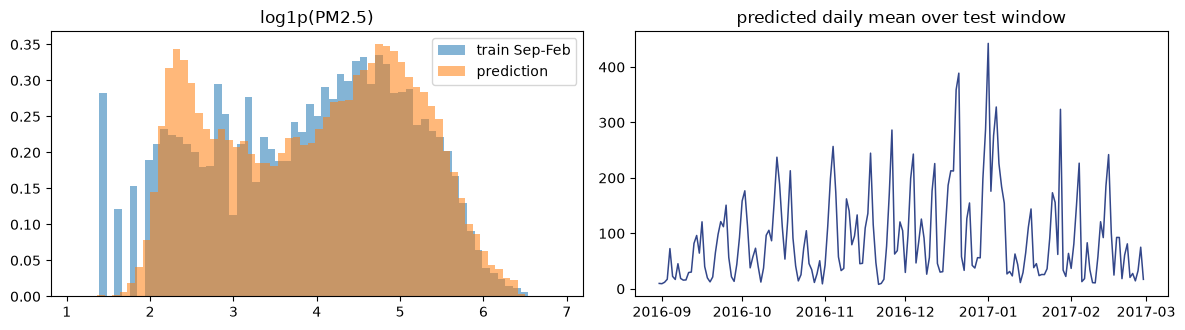

In [20]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
ax[0].hist(np.log1p(win), bins=60, alpha=0.55, density=True, label="train Sep-Feb")
ax[0].hist(np.log1p(sub[TARGET]), bins=60, alpha=0.55, density=True, label="prediction")
ax[0].set_title("log1p(PM2.5)"); ax[0].legend()
d = test[[TIME]].assign(p=final).set_index(TIME)["p"].resample("D").mean()
ax[1].plot(d.index, d.values, lw=1.1, color="#33478a")
ax[1].set_title("predicted daily mean over test window")
plt.tight_layout(); plt.show()

## 12. Run order

1. `QUICK = True`, `STRICT_MODE = True` — verify the pipeline end to end in a few minutes.
2. `QUICK = False`, `STRICT_MODE = True` — your defensible submission. Note the blend OOF.
3. `STRICT_MODE = False` — note the blend OOF again.

The difference between runs 2 and 3 is what the lead block is worth. You need that number before you ask
the organisers about it, and you should ask before submitting anything from run 3.

**Two diagnostics worth reading rather than skipping:**

- The anchor's out-of-time nowcast RMSE in §6. If the anchor features carry no gain in the §8
  importance table under `STRICT_MODE = False`, set `USE_ANCHOR = False` for that mode — the lead block
  has superseded it and you are paying training time for nothing.
- The decile bias table in §10. Even when the LOFO guard rejects the correction, systematic
  underprediction in the top decile tells you where your RMSE is going.

**Remaining gains, descending:**

1. Improve the nowcast model `g` — it propagates into every anchor feature.
2. Residual target: fit on `y − pm25_hat` instead of `y`. This is the delta target the missing
   `current_PM2_5` column was meant to enable. One CV run tells you whether it beats direct prediction.
3. More hygroscopic forms. It was B's highest-gain family; there is probably more there.
4. Per-station models blended against the global one.
5. A spatio-temporal GNN over the 12 stations, edges weighted by the §4 correlation matrix and gated by
   wind. The one architecture that could beat the trees rather than just diversify them.